In [1]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from scipy.optimize import minimize
from astropy.convolution import Gaussian1DKernel
import scipy.integrate as integrate
from scipy.optimize import differential_evolution
import plotly.express as px

In [2]:
hdul = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/Reduced/Mrk-544_MAPPED_FLUX_SCI_LSS_U1.fits")
hdul.info()
image = hdul[0].data

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/Reduced/Mrk-544_MAPPED_FLUX_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     365   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        46   (2094, 964)   float32   


In [3]:
image_cut = image[55:155, 0:1800]

Text(0.5, 0, 'wavelenght')

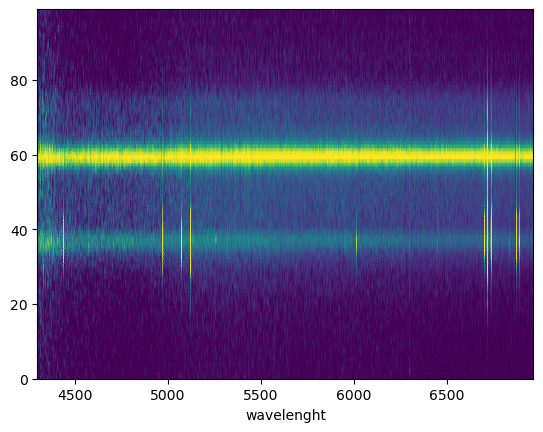

In [4]:
wavelenghts = np.arange(4300.74, 4300.74+1800*1.48, 1.48)
J, N = image_cut.data.shape
#x = np.arange(0, N, 1)
y = np.arange(0, J, 1)
arcsec_y = np.arange(-58*0.256, 42*0.256, 0.256)

x_grid, y_grid = np.meshgrid(wavelenghts, y)
plt.pcolormesh(x_grid, y_grid, image_cut, shading='gouraud', vmin = np.percentile(image_cut, 20), vmax = 0.16)
plt.xlabel('wavelenght')

## Redshift or the lines in air

In [5]:
z = 0.0238
l_HA = 6563 * (1+z)
l_HB = 4861 * (1+z) 
l_NII = 6583 * (1+z)
l_SII = 6717 * (1+z)
l_OIII = 5007 * (1+z)

## H$\alpha$

Text(0.5, 1.0, 'H$\\alpha$')

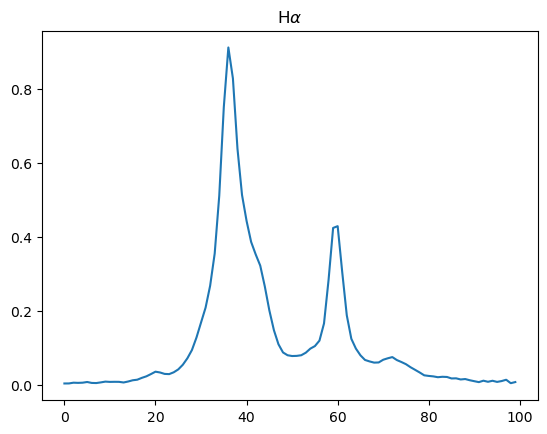

In [6]:
mask_HA = (wavelenghts > l_HA-10)*(wavelenghts < l_HA+10)
image_HA = image_cut[:, mask_HA]
radial_profile_HA = np.mean(image_HA, axis = 1)
x_axes = np.arange(0, 100, 1)
plt.plot(x_axes, radial_profile_HA)
plt.title(r'H$\alpha$')

differential_evolution step 1: f(x)= 2.7913496325670395
differential_evolution step 2: f(x)= 2.3649466092602296
differential_evolution step 3: f(x)= 1.2814029111075131
differential_evolution step 4: f(x)= 1.2814029111075131
differential_evolution step 5: f(x)= 1.2814029111075131
differential_evolution step 6: f(x)= 0.9848267281170975
differential_evolution step 7: f(x)= 0.7359026500973508
differential_evolution step 8: f(x)= 0.5887235505526568
differential_evolution step 9: f(x)= 0.5887235505526568
differential_evolution step 10: f(x)= 0.5887235505526568
differential_evolution step 11: f(x)= 0.5887235505526568
differential_evolution step 12: f(x)= 0.4986363229003155
differential_evolution step 13: f(x)= 0.4986363229003155
differential_evolution step 14: f(x)= 0.4986363229003155
differential_evolution step 15: f(x)= 0.4234990566001264
differential_evolution step 16: f(x)= 0.3857247170678535
differential_evolution step 17: f(x)= 0.3857247170678535
differential_evolution step 18: f(x)= 0.

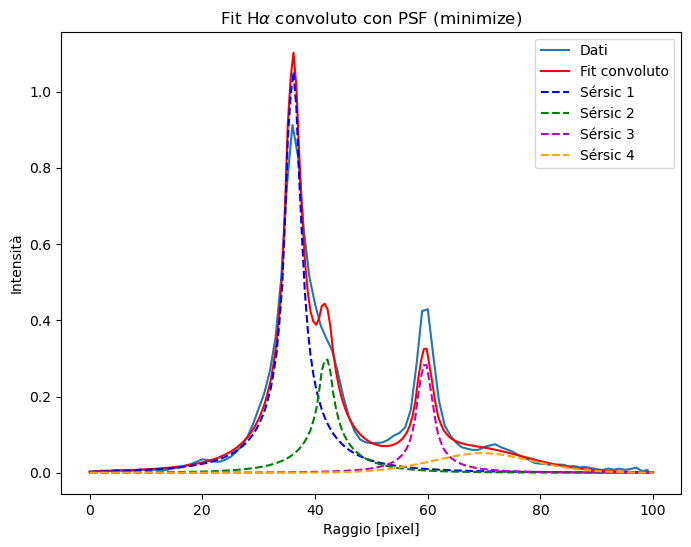

Parametri ottimizzati 1:
 [ 0.04103504 12.11558779  2.38190741 35.64816302]
Parametri ottimizzati 2:
 [2.21163856e-02 9.47002438e+00 1.70013944e+00 4.14778493e+01]
Parametri ottimizzati 3:
 [1.19019033e-02 9.20531684e+00 2.60382442e+00 5.90240034e+01]
Parametri ottimizzati 4:
 [2.42888408e-02 1.08913914e+01 5.32997193e-01 6.91525979e+01]


(-0.2, 0.2)

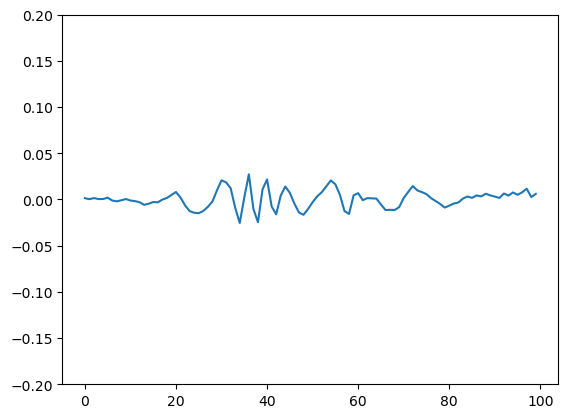

In [24]:
sigma = 3.125/2.35

def calculate_bn(n): #Evaluate B_n for the sersic profile 
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, I_e, r_e, n, x_0): #Sersic profile centered in x0
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r/r_e)**(1/n) - 1))

def sersic_1d_convolved(x, I_e, r_e, n, x_0): #Convolved sersic profile with the psf
    x_hr = np.linspace(min(x), max(x), 100)
    profile = sersic_1d(x_hr, I_e, r_e, n, x_0)
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   #The PSF is a gaussian centered in 0!
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def model_convolved(x, *params):
    return (sersic_1d_convolved(x, *params[0:4]) + sersic_1d_convolved(x, *params[4:8]) + sersic_1d_convolved(x, *params[8:12]) +
        sersic_1d_convolved(x, *params[12:16])) 

def chi_squared(params, x, y_obs):
    #I_e1, r_e1, n1, x_01, I_e2, r_e2, n2, x_02, I_e3, r_e3, n3, x_03, I_e4, r_e4, n4, x_04 = params
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

bounds = [(0, 0.1), (2, 20), (0.1, 10), (20, 40),   (0., 0.1), (2, 20), (0.1, 10), (40, 50), 
          (0., 0.1), (2, 20), (0.1, 10), (53, 60),   (0., 0.1), (2, 20), (0.1, 10), (65, 75) ]

def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA)
    
result = differential_evolution(objective, bounds, maxiter = 200, disp = True, polish = True, tol = 1e-6)
best_params = result.x

xgrid = np.linspace(0, 100, 200)
y_fit = model_convolved(xgrid, *best_params)
y_fit_data = model_convolved(x_axes, *best_params)

plt.figure(figsize=(8, 6))
plt.plot(x_axes, radial_profile_HA, label='Dati')
plt.plot(xgrid, y_fit, 'r-', label='Fit convoluto')

# Componenti singoli
plt.plot(xgrid, sersic_1d_convolved(xgrid, *best_params[0:4]), 'b--', label='Sérsic 1')
plt.plot(xgrid, sersic_1d_convolved(xgrid, *best_params[4:8]), 'g--', label='Sérsic 2')
plt.plot(xgrid, sersic_1d_convolved(xgrid, *best_params[8:12]), 'm--', label='Sérsic 3')
plt.plot(xgrid, sersic_1d_convolved(xgrid, *best_params[12:16]), 'orange', linestyle='--', label='Sérsic 4')

plt.xlabel("Raggio [pixel]")
plt.ylabel("Intensità")
plt.title(r"Fit H$\alpha$ convoluto con PSF (minimize)")
plt.legend()
plt.show()
print("Parametri ottimizzati 1:\n", best_params[0:4])
print("Parametri ottimizzati 2:\n", best_params[4:8])
print("Parametri ottimizzati 3:\n", best_params[8:12])
print("Parametri ottimizzati 4:\n", best_params[12:16])

plt.plot(x_axes, radial_profile_HA - y_fit_data)
plt.ylim(-0.2, 0.2)

## Grid(200) and Kernel

In [44]:
sigma = 3.125 / 2.35

def calculate_bn(n):
    """ Calcola b_n per il profilo Sérsic """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, I_e, r_e, n, x_0):
    """ Profilo Sérsic 1D centrato in x_0 """
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))

def sersic_1d_convolved(x, I_e, r_e, n, x_0): #Convolved sersic profile with the psf
    x_hr = np.linspace(min(x), max(x), 200)
    profile = sersic_1d(x_hr, I_e, r_e, n, x_0)
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   #The PSF is a gaussian centered in 0!
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def model_convolved(x, *params):
    """ Somma di 4 Sérsic convoluti """
    return (
        sersic_1d_convolved(x, *params[0:4]) +
        sersic_1d_convolved(x, *params[4:8]) +
        sersic_1d_convolved(x, *params[8:12]) +
        sersic_1d_convolved(x, *params[12:16])
    )

def chi_squared(params, x, y_obs):
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds = [
    (0, 0.1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (2, 10),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (20, 40),   # x_0: posizione da 0 a 100

    (0, 0.1),
    (2, 10),
    (0.1, 10),
    (40, 50),

    (0, 0.1),
    (2, 10),
    (0.1, 10),
    (50, 70),

    (0, 0.1),
    (2, 10),
    (0.1, 10),
    (70, 80)
]

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=100,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(4):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

differential_evolution step 1: f(x)= 2.4197882605569445
differential_evolution step 2: f(x)= 1.717309109936944
differential_evolution step 3: f(x)= 1.717309109936944
differential_evolution step 4: f(x)= 1.717309109936944
differential_evolution step 5: f(x)= 0.9826409472568026
differential_evolution step 6: f(x)= 0.4450616463996979
differential_evolution step 7: f(x)= 0.4255097619350203
differential_evolution step 8: f(x)= 0.3757338851083975
differential_evolution step 9: f(x)= 0.3757338851083975
differential_evolution step 10: f(x)= 0.3757338851083975
differential_evolution step 11: f(x)= 0.3757338851083975
differential_evolution step 12: f(x)= 0.3757338851083975
differential_evolution step 13: f(x)= 0.3757338851083975
differential_evolution step 14: f(x)= 0.3757338851083975
differential_evolution step 15: f(x)= 0.3757338851083975
differential_evolution step 16: f(x)= 0.22788546941475302
differential_evolution step 17: f(x)= 0.17684520845763788
differential_evolution step 18: f(x)= 0.1

(-0.2, 0.2)

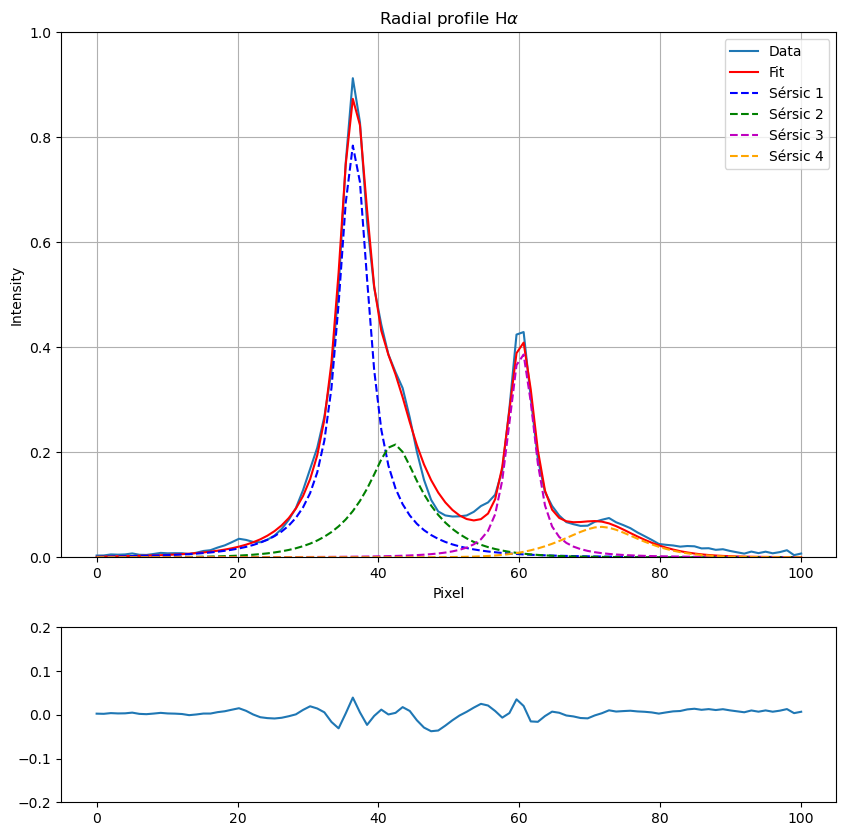

In [45]:
# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *best_params)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

ax[0].plot(x_axes, radial_profile_HA, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[12:16]), color='orange', linestyle='--', label='Sérsic 4')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\alpha$")
ax[0].legend()
ax[0].grid(True)
ax[0].set_ylim(0, 1)
#ax[0].tight_layout()

ax[1].plot(x_axes, radial_profile_HA - y_fit)
ax[1].set_ylim(-0.2, 0.2)

## Grid(100) and no kernel

In [31]:
sigma = 3.125 / 2.35

def calculate_bn(n):
    """ Calcola b_n per il profilo Sérsic """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, I_e, r_e, n, x_0):
    """ Profilo Sérsic 1D centrato in x_0 """
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))

def gaussian_psf(x, sigma):
    """ PSF gaussiana normalizzata """
    psf = np.exp(-x**2 / (2 * sigma**2))
    return psf / np.sum(psf)

def sersic_1d_convolved(x, I_e, r_e, n, x_0): #Convolved sersic profile with the psf
    x_hr = np.linspace(min(x), max(x), 100)
    profile = sersic_1d(x_hr, I_e, r_e, n, x_0)
    kernel = gaussian_psf(x_hr, sigma = (sigma*len(x_hr))/len(x))   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def model_convolved(x, *params):
    """ Somma di 4 Sérsic convoluti """
    return (
        sersic_1d_convolved(x, *params[0:4]) +
        sersic_1d_convolved(x, *params[4:8]) +
        sersic_1d_convolved(x, *params[8:12]) +
        sersic_1d_convolved(x, *params[12:16])
    )

def chi_squared(params, x, y_obs):
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds = [
    (0, 0.1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (2, 10),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (20, 40),   # x_0: posizione da 0 a 100

    (0, 0.1),
    (2, 10),
    (0.1, 10),
    (40, 50),

    (0, 0.1),
    (2, 10),
    (0.1, 10),
    (50, 70),

    (0, 0.1),
    (2, 10),
    (0.1, 10),
    (70, 80)
]

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=100,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(4):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

differential_evolution step 1: f(x)= 3.5786495030657544
differential_evolution step 2: f(x)= 3.1281702275280896
differential_evolution step 3: f(x)= 3.1281702275280896
differential_evolution step 4: f(x)= 3.1281702275280896
differential_evolution step 5: f(x)= 3.1281702275280896
differential_evolution step 6: f(x)= 3.1281702275280896
differential_evolution step 7: f(x)= 3.1281702275280896
differential_evolution step 8: f(x)= 3.1281702275280896
differential_evolution step 9: f(x)= 3.1281702275280896
differential_evolution step 10: f(x)= 3.1281702275280896
differential_evolution step 11: f(x)= 3.117606436936968
differential_evolution step 12: f(x)= 3.0339327506120912
differential_evolution step 13: f(x)= 3.0339327506120912
differential_evolution step 14: f(x)= 2.9081804439112213
differential_evolution step 15: f(x)= 2.9081804439112213
differential_evolution step 16: f(x)= 2.9081804439112213
differential_evolution step 17: f(x)= 2.9081804439112213
differential_evolution step 18: f(x)= 2.8

(-0.2, 0.2)

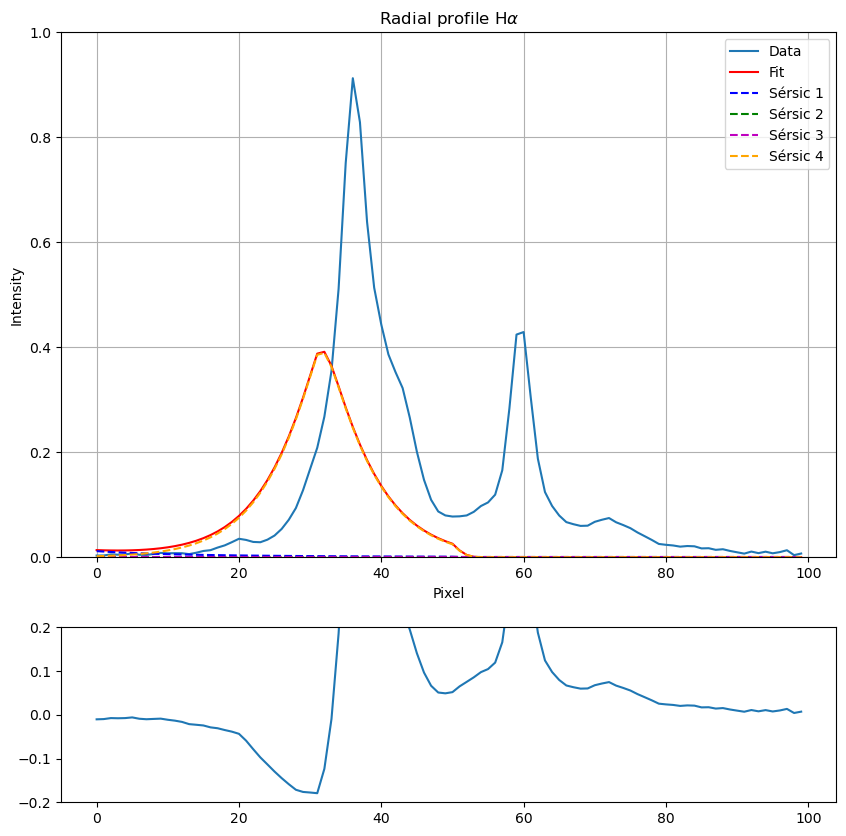

In [33]:
# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *best_params)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

ax[0].plot(x_axes, radial_profile_HA, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[12:16]), color='orange', linestyle='--', label='Sérsic 4')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\alpha$")
ax[0].legend()
ax[0].grid(True)
ax[0].set_ylim(0, 1)
#ax[0].tight_layout()

ax[1].plot(x_axes, radial_profile_HA - y_fit)
ax[1].set_ylim(-0.2, 0.2)

## No grid with Kernel

In [34]:
sigma = 3.125 / 2.35

def calculate_bn(n):
    """ Calcola b_n per il profilo Sérsic """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, I_e, r_e, n, x_0):
    """ Profilo Sérsic 1D centrato in x_0 """
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))

def sersic_1d_convolved(x, I_e, r_e, n, x_0):
    """ Sérsic convoluto con PSF gaussiana """
    profile = sersic_1d(x, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev = sigma, mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    return conv_profile

def model_convolved(x, *params):
    """ Somma di 4 Sérsic convoluti """
    return (
        sersic_1d_convolved(x, *params[0:4]) +
        sersic_1d_convolved(x, *params[4:8]) +
        sersic_1d_convolved(x, *params[8:12]) +
        sersic_1d_convolved(x, *params[12:16])
    )

def chi_squared(params, x, y_obs):
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds = [
    (0, 0.1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (2, 10),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (20, 40),   # x_0: posizione da 0 a 100

    (0, 0.1),
    (2, 10),
    (0.1, 10),
    (40, 50),

    (0, 0.1),
    (2, 10),
    (0.1, 10),
    (50, 70),

    (0, 0.1),
    (2, 10),
    (0.1, 10),
    (70, 80)
]

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=100,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(4):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

differential_evolution step 1: f(x)= 2.0555657350408665
differential_evolution step 2: f(x)= 2.0555657350408665
differential_evolution step 3: f(x)= 1.9802855138079152
differential_evolution step 4: f(x)= 1.0458586483194767
differential_evolution step 5: f(x)= 1.014755978045737
differential_evolution step 6: f(x)= 1.014755978045737
differential_evolution step 7: f(x)= 1.014755978045737
differential_evolution step 8: f(x)= 1.014755978045737
differential_evolution step 9: f(x)= 0.7218967787276761
differential_evolution step 10: f(x)= 0.6609869355231519
differential_evolution step 11: f(x)= 0.5001631871996112
differential_evolution step 12: f(x)= 0.4533064085354933
differential_evolution step 13: f(x)= 0.4533064085354933
differential_evolution step 14: f(x)= 0.4533064085354933
differential_evolution step 15: f(x)= 0.4533064085354933
differential_evolution step 16: f(x)= 0.4533064085354933
differential_evolution step 17: f(x)= 0.4533064085354933
differential_evolution step 18: f(x)= 0.4533

(-0.2, 0.2)

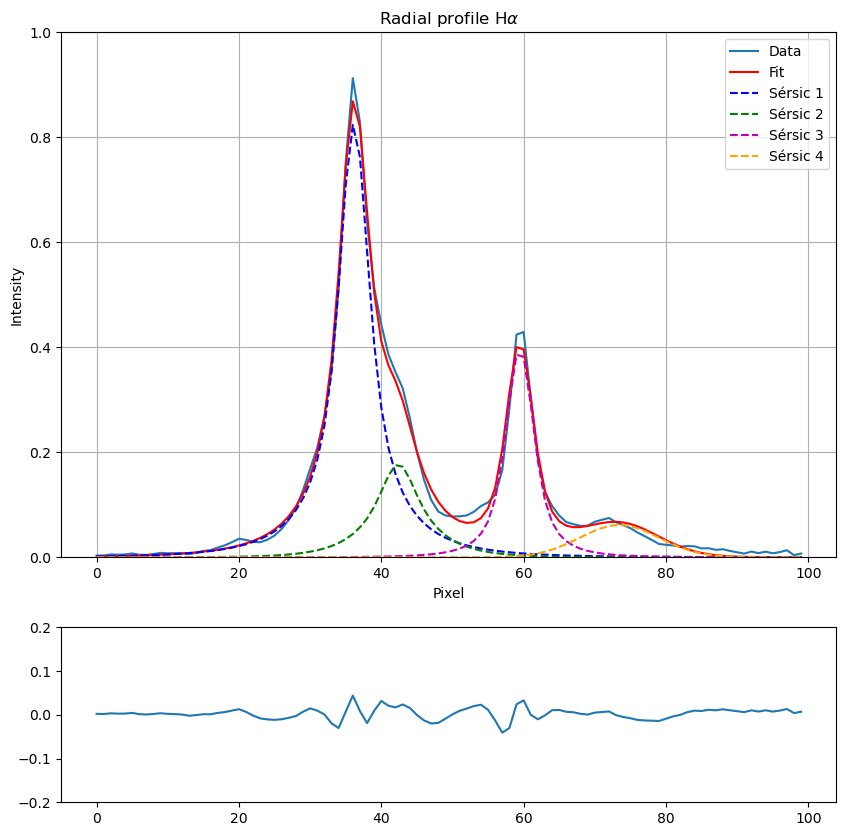

In [35]:
# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *best_params)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

ax[0].plot(x_axes, radial_profile_HA, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[12:16]), color='orange', linestyle='--', label='Sérsic 4')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\alpha$")
ax[0].legend()
ax[0].grid(True)
ax[0].set_ylim(0, 1)
#ax[0].tight_layout()

ax[1].plot(x_axes, radial_profile_HA - y_fit)
ax[1].set_ylim(-0.2, 0.2)

In [7]:
sigma = 3.125 / 2.35

def calculate_bn(n):
    """ Calcola b_n per il profilo Sérsic """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, I_e, r_e, n, x_0):
    """ Profilo Sérsic 1D centrato in x_0 """
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))

def gaussian_psf(x, sigma):
    """ PSF gaussiana normalizzata """
    psf = np.exp(-x**2 / (2 * sigma**2))
    return psf / np.sum(psf)

def sersic_1d_convolved(x, I_e, r_e, n, x_0, sigma):
    """ Sérsic convoluto con PSF gaussiana """
    profile = sersic_1d(x, I_e, r_e, n, x_0)
    psf_x = x - x[len(x)//2]
    psf = gaussian_psf(psf_x, sigma)
    conv_profile = convolve(profile, psf, mode='same')
    return conv_profile

def model_convolved(x, *params, sigma):
    """ Somma di 4 Sérsic convoluti """
    return (
        sersic_1d_convolved(x, *params[0:4], sigma) +
        sersic_1d_convolved(x, *params[4:8], sigma) +
        sersic_1d_convolved(x, *params[8:12], sigma) +
        sersic_1d_convolved(x, *params[12:16], sigma)
    )

def chi_squared(params, x, y_obs, sigma):
    y_model = model_convolved(x, *params, sigma=sigma)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds = [
    (0, 0.1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (2, 10),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (20, 40),   # x_0: posizione da 0 a 100

    (0, 0.1),
    (2, 10),
    (0.1, 10),
    (40, 50),

    (0, 0.1),
    (2, 10),
    (0.1, 10),
    (50, 70),

    (0, 0.1),
    (2, 10),
    (0.1, 10),
    (70, 80)
]

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA, sigma)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=100,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(4):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

differential_evolution step 1: f(x)= 1.5908437715094161
differential_evolution step 2: f(x)= 1.5908437715094161
differential_evolution step 3: f(x)= 1.5908437715094161
differential_evolution step 4: f(x)= 1.1358353399518466
differential_evolution step 5: f(x)= 0.7353456049016016
differential_evolution step 6: f(x)= 0.7353456049016016
differential_evolution step 7: f(x)= 0.7353456049016016
differential_evolution step 8: f(x)= 0.7353456049016016
differential_evolution step 9: f(x)= 0.4869897975203986
differential_evolution step 10: f(x)= 0.4869897975203986
differential_evolution step 11: f(x)= 0.4869897975203986
differential_evolution step 12: f(x)= 0.4869897975203986
differential_evolution step 13: f(x)= 0.4869897975203986
differential_evolution step 14: f(x)= 0.4869897975203986
differential_evolution step 15: f(x)= 0.4869897975203986
differential_evolution step 16: f(x)= 0.4869897975203986
differential_evolution step 17: f(x)= 0.3900448497589041
differential_evolution step 18: f(x)= 0.

ValueError: x and y must have same first dimension, but have shapes (100,) and (200,)

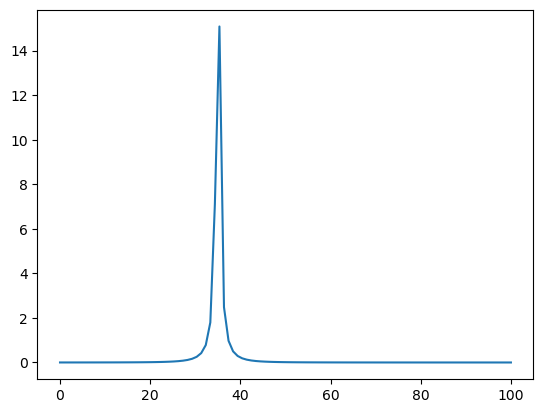

In [37]:
x_axes = np.linspace(0, 100, 100)

def sersic_1d_convolved(x, I_e, r_e, n, x_0, sigma):
    """ Sérsic convoluto con PSF gaussiana """
    profile = sersic_1d(x, I_e, r_e, n, x_0)
    psf_x = x - x[len(x)//2]
    psf = gaussian_psf(psf_x, sigma)
    conv_profile = convolve(profile, psf, mode='same')
    return profile, kernel, conv_profile

profile, kernel, conv_profile = sersic_1d_convolved(x_axes, 0.63, 3, 4, 35, sigma)

plt.plot(x_axes, profile, label = 'profile')
plt.plot(x_axes, kernel, label = 'kernel')
plt.plot(x_axes, conv_profile, label = 'conv_profile')
plt.legend()
len(x_axes)

import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Scatter(x=x_axes, y=profile, mode='lines', name='Profile'))
fig.add_trace(go.Scatter(x=x_axes, y=kernel, mode='lines', name='PSF'))
fig.add_trace(go.Scatter(x=x_axes, y=conv_profile, mode='lines', name='Convolved Profile'))

fig.update_layout(
    title='Line Profiles',
    xaxis_title='wv',
    yaxis_title='Flux',
    legend_title='Curve Type'
)

fig.show()

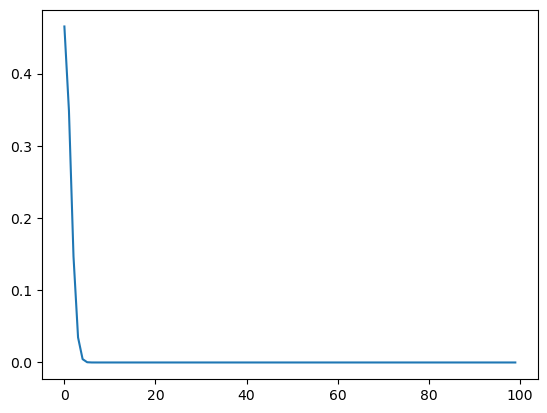

In [45]:
plt.plot(gaussian_psf(x_axes, sigma))

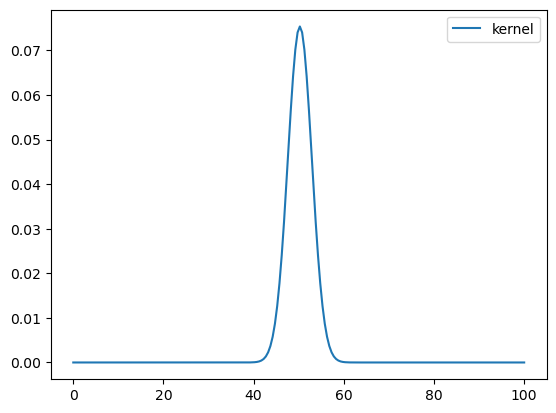

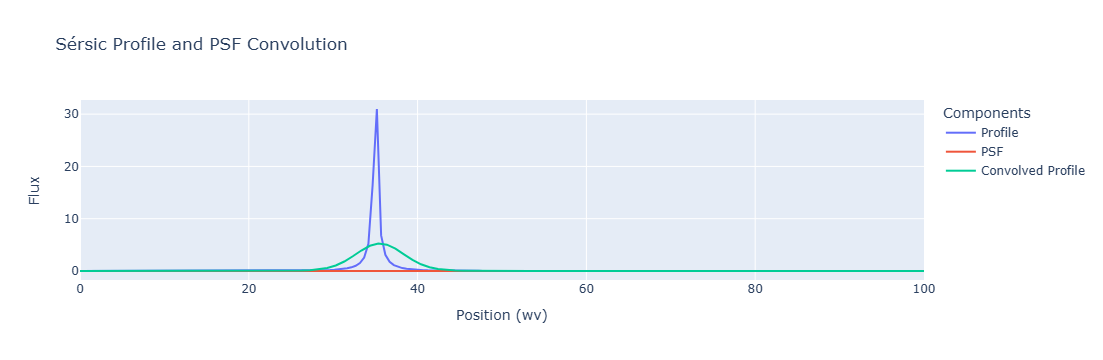

In [39]:
sigma = 3.125 / 2.35

def calculate_bn(n):
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, I_e, r_e, n, x_0):
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))

def gaussian_psf(x, sigma):
    psf = np.exp(-x**2 / (2 * sigma**2))
    return psf / np.sum(psf)

def sersic_1d_convolved(x, I_e, r_e, n, x_0):
    x_hr = np.linspace(min(x), max(x), 200)
    profile = sersic_1d(x_hr, I_e, r_e, n, x_0)
    psf_x = x_hr - x_hr[len(x_hr)//2]
    kernel = gaussian_psf(psf_x, sigma=(sigma * len(x_hr)) / len(x))   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return x_hr, profile, kernel, conv_profile_out

x_axes = np.linspace(0, 100, 100)
x_hr, profile, kernel, conv_profile = sersic_1d_convolved(x_axes, 0.63, 3, 4, 35)

plt.plot(x_hr, kernel, label='kernel')

plt.legend()
plt.show()

fig = go.Figure()

fig.add_trace(go.Scatter(x=x_hr, y=profile, mode='lines', name='Profile'))
fig.add_trace(go.Scatter(x=x_hr, y=kernel, mode='lines', name='PSF'))
fig.add_trace(go.Scatter(x=x_axes, y=conv_profile, mode='lines', name='Convolved Profile'))

fig.update_layout(
    title='Sérsic Profile and PSF Convolution',
    xaxis_title='Position (wv)',
    yaxis_title='Flux',
    legend_title='Components'
)

fig.show()


In [27]:
conv_profile.shape

(100,)

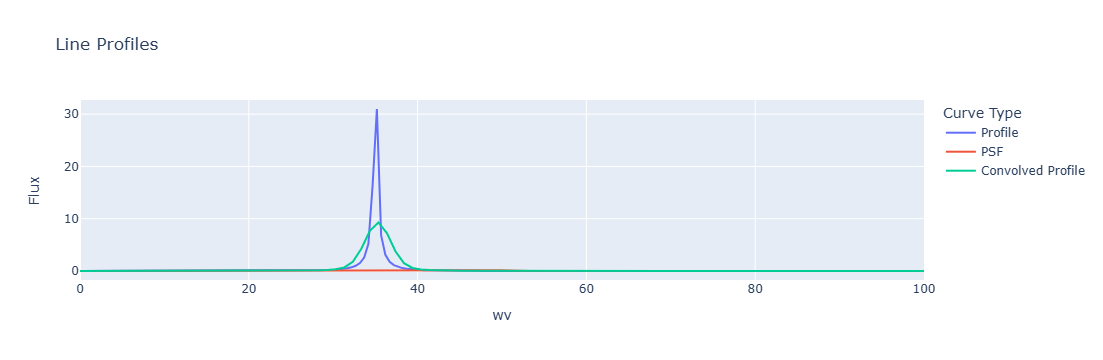

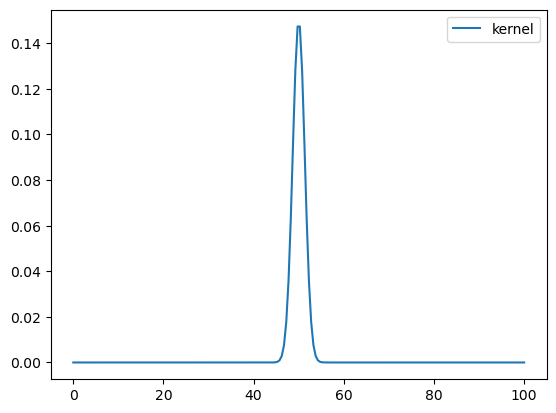

In [38]:
def sersic_1d_convolved(x, I_e, r_e, n, x_0): #Convolved sersic profile with the psf
    x_hr = np.linspace(min(x), max(x), 200)
    profile = sersic_1d(x_hr, I_e, r_e, n, x_0)
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   #The PSF is a gaussian centered in 0!
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return x_hr, profile, kernel, conv_profile_out

x_axes = np.linspace(0, 100, 100)
#x_hr = np.linspace(min(x_axes), max(x_axes), 200)
x_hr, profile, kernel, conv_profile = sersic_1d_convolved(x_axes, 0.63, 3, 4, 35) 

plt.plot(x_hr, kernel, label = 'kernel')

plt.legend()
len(x_axes)

import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Scatter(x=x_hr, y=profile, mode='lines', name='Profile'))
fig.add_trace(go.Scatter(x=x_hr, y=kernel, mode='lines', name='PSF'))
fig.add_trace(go.Scatter(x=x_axes, y=conv_profile, mode='lines', name='Convolved Profile'))

fig.update_layout(
    title='Line Profiles',
    xaxis_title='wv',
    yaxis_title='Flux',
    legend_title='Curve Type'
)

fig.show()

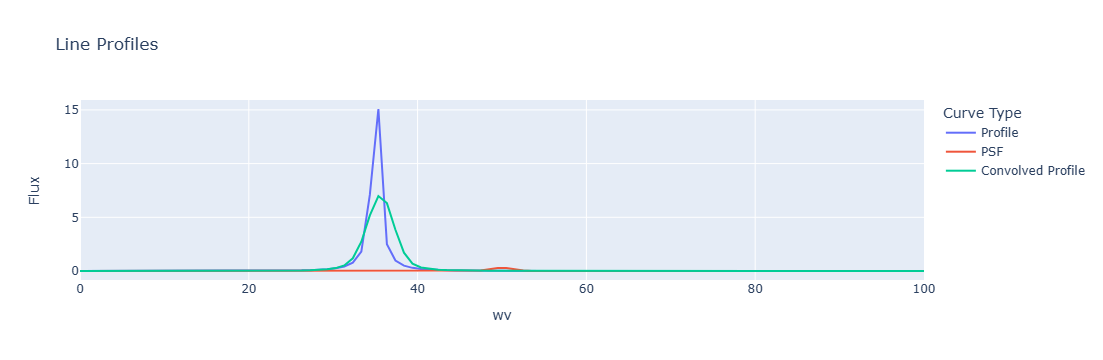

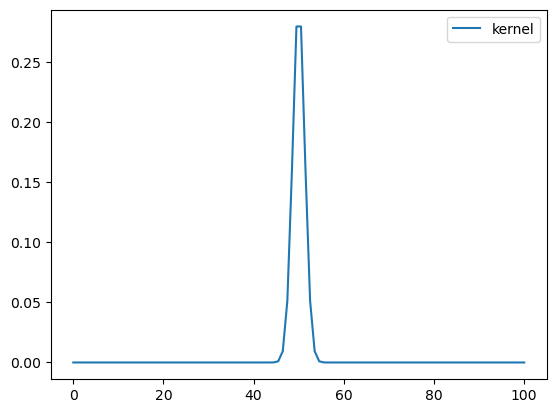

In [43]:
def sersic_1d_convolved(x, I_e, r_e, n, x_0):
    """ Sérsic convoluto con PSF gaussiana """
    profile = sersic_1d(x, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev = sigma, x_size=len(x),  mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    return profile, psf, conv_profile

x_axes = np.linspace(0, 100, 100)
#x_hr = np.linspace(min(x_axes), max(x_axes), 200)
profile, kernel, conv_profile = sersic_1d_convolved(x_axes, 0.63, 3, 4, 35) 

plt.plot(x_axes, kernel, label = 'kernel')

plt.legend()
len(x_axes)

import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Scatter(x=x_axes, y=profile, mode='lines', name='Profile'))
fig.add_trace(go.Scatter(x=x_axes, y=kernel, mode='lines', name='PSF'))
fig.add_trace(go.Scatter(x=x_axes, y=conv_profile, mode='lines', name='Convolved Profile'))

fig.update_layout(
    title='Line Profiles',
    xaxis_title='wv',
    yaxis_title='Flux',
    legend_title='Curve Type'
)

fig.show()